# Engenharia de variáveis e o que a base sustenta

**Projeto de extensão AACD — notebook 02**

O notebook 01 arrumou a base. Este transforma as variáveis em algo que modelo
entende, aplica os valores normativos brasileiros do documento da equipe de
fisioterapia, e responde à pergunta que a AACD fez de forma mais direta:

> *"Quais testes realmente ajudam a identificar quem cai, e quais dão trabalho
> mas não diferenciam ninguém?"*

### Duas correções em relação ao notebook 01

O documento *Interpretação dos componentes inseridos na planilha* corrigiu duas
coisas que eu havia concluído errado:

| O que eu disse | O que é de fato |
|---|---|
| Circunferência do braço tem 92% de lacuna, descartar | É a **medida substituta** da panturrilha em amputação e lesão medular. A seção 3 prova isso nos dados. |
| Corte de sarcopenia: < 30 kg ♂ / < 20 kg ♀ | Esses são do EWGSOP**1**. O EWGSOP2 (2019) usa **< 27 / < 16**, e a diferença muda a prevalência em 21 pontos. |

E uma correção de método: ponte e sentar/levantar **não devem ser fundidos num só
número**. O documento é explícito — *"exige tratamento estatístico separado"*. No
notebook 01 eu usei uma variável combinada no escore; aqui ela é tratada como
estratificação.

---

### Roteiro

| Seção | O que faz |
|---|---|
| 1 | Codificação: `M`/`F` → 0/1, e os outros três tipos de encoding |
| 2 | Normalização pelos normativos brasileiros (z-score e % do esperado) |
| 3 | O retrato revisado: o que está preservado e o que está comprometido |
| 4 | Redundância: quais testes repetem informação |
| 5 | PCA: quantas dimensões reais tem a bateria |
| 6 | Perfis de paciente (clusterização) |
| 7 | O teto honesto de modelagem |
| 8 | O que dá para fazer com o que temos |

## 0. Preparação

Depende de `saidas/base_tratada.csv`, gerado pelo notebook 01. Rode aquele
primeiro se este arquivo não existir.

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

sys.path.insert(0, "scripts")
import normativos as nz          # tabelas normativas com a fonte de cada valor

CAMINHO = "saidas/base_tratada.csv"
if not os.path.exists(CAMINHO):
    raise FileNotFoundError(
        "Rode o notebook 01 (analise_quedas_aacd.ipynb) primeiro — "
        "ele gera saidas/base_tratada.csv.")

base = pd.read_csv(CAMINHO)
mais = base[base["aba"] == "60+"].reset_index(drop=True)
menos = base[base["aba"] == "60-"].reset_index(drop=True)
print(f"60+ : {len(mais)} pacientes · 60- : {len(menos)} pacientes")

# Paleta validada (CVD + contraste), igual à do notebook 01.
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
AMARELO, MAGENTA, VERMELHO, VIOLETA = "#eda100", "#e87ba4", "#e34948", "#4a3aa7"
SUPERFICIE, TINTA, TINTA2, CINZA = "#fcfcfb", "#0b0b0b", "#52514e", "#c9c7c0"
AZUIS = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]
NEUTRO_DIV = "#f0efec"      # midpoint neutro da escala divergente

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "savefig.bbox": "tight",
    "axes.edgecolor": TINTA2, "axes.labelcolor": TINTA2, "text.color": TINTA,
    "xtick.color": TINTA2, "ytick.color": TINTA2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
    "font.size": 10, "figure.dpi": 110,
})


def rotule(ax, titulo, sub=None, xlab=None, ylab=None):
    ax.text(0, 1.13 if sub else 1.04, titulo, transform=ax.transAxes,
            fontsize=12, fontweight="bold", color=TINTA, va="bottom")
    if sub:
        ax.text(0, 1.03, sub, transform=ax.transAxes, fontsize=9.5,
                color=TINTA2, va="bottom")
    ax.set_xlabel(xlab or "")
    ax.set_ylabel(ylab or "")


so_x = lambda ax: (ax.grid(axis="y", visible=False), ax.grid(axis="x", visible=True))
so_y = lambda ax: (ax.grid(axis="x", visible=False), ax.grid(axis="y", visible=True))
print("Ambiente pronto.")

60+ : 166 pacientes · 60- : 116 pacientes
Ambiente pronto.


---
## 1. Codificação: de texto para número

Modelo não entende `"M"`, `"Andador reciprocado"` nem `"Marcha domiciliar"`. Mas
não existe um jeito único de converter: **o tipo de encoding depende do que a
variável significa.** Usar o errado inventa ordem onde não existe, ou apaga ordem
que existe.

| Tipo de variável | Encoding certo | Por quê |
|---|---|---|
| Binária (`sexo`, `polifarmácia`) | 0/1 | duas categorias, nada a ordenar |
| **Ordinal** (`CIF`, aditamento, nível de marcha) | inteiro **com ordem** | a ordem é informação clínica |
| Nominal (`diagnóstico`, suporte) | one-hot | nenhuma ordem existe entre AMP e Polio |
| Contínua | mantém, mas normaliza (seção 2) | — |

O erro clássico aqui seria codificar `diagnóstico` como 1=AMP, 2=LEA, 3=LM: o
modelo passaria a achar que LM é "o triplo de" AMP, o que não quer dizer nada.

In [2]:
# ── 1a. Binárias: o 'M e F para 0 e 1' ───────────────────────────────────────
# Convenção explícita, documentada: 1 = a condição que o nome descreve.
BINARIAS = {
    "sexo":              {"M": 0, "F": 1},     # 1 = feminino
    "posicao_equilibrio": {"sentado": 0, "ortostatismo": 1},   # 1 = em pé
}


def codifica_binarias(df):
    d = df.copy()
    d["sexo_fem"] = d["sexo"].map(BINARIAS["sexo"]).astype("Int8")
    d["equilibrio_em_pe"] = d["posicao_equilibrio"].map(
        BINARIAS["posicao_equilibrio"]).astype("Int8")
    # As colunas já booleanas viram 0/1 preservando o nulo.
    for col in ["polifarmacia", "supervisao", "caiu", "queda_recorrente",
                "queda_ultimo_mes"]:
        d[f"{col}_bin"] = d[col].astype("boolean").astype("Int8")
    return d


mais = codifica_binarias(mais)
menos = codifica_binarias(menos)

mais[["sexo", "sexo_fem", "polifarmacia", "polifarmacia_bin",
      "posicao_equilibrio", "equilibrio_em_pe", "caiu", "caiu_bin"]].head(8)

,sexo,sexo_fem,polifarmacia,polifarmacia_bin,posicao_equilibrio,equilibrio_em_pe,caiu,caiu_bin
0,M,0,NaN,<NA>,sentado,0,True,1
1,M,0,NaN,<NA>,sentado,0,False,0
2,F,1,False,0,sentado,0,False,0
3,M,0,NaN,<NA>,ortostatismo,1,True,1
4,F,1,NaN,<NA>,ortostatismo,1,True,1
5,F,1,NaN,<NA>,ortostatismo,1,True,1
6,F,1,NaN,<NA>,ortostatismo,1,True,1
7,M,0,NaN,<NA>,sentado,0,True,1


In [3]:
# ── 1b. Ordinais: a ordem É a informação ────────────────────────────────────
# Aditamento, ordenado por quanto apoio o dispositivo oferece. O documento diz
# que o dispositivo "pode ser um marcador de maior limitação funcional" — ou
# seja, a escada abaixo tem sentido clínico, não é arbitrária.
ORDEM_ADITAMENTO = {
    "nenhum": 0, "bastão": 1, "bengala": 2, "muleta": 3,
    "andador": 4, "cadeira de rodas": 5,
}
# Nível de marcha, ordenado por alcance. Cadeira de rodas fica FORA desta escala:
# não é "marcha curta", é outro modo de locomoção (ver notebook 01, seção 8).
ORDEM_MARCHA = {"terapêutica": 0, "domiciliar": 1, "comunitária": 2}


def codifica_ordinais(df):
    d = df.copy()
    d["aditamento_ord"] = d["aditamento_grupo"].map(ORDEM_ADITAMENTO).astype("Int8")
    d["nivel_marcha_ord"] = d["nivel_marcha"].map(ORDEM_MARCHA).astype("Int8")
    d["usa_cadeira"] = d["perfil_mobilidade"].isin(
        ["só cadeira de rodas", "misto (anda e usa cadeira)"]).astype("Int8")
    d["anda"] = d["perfil_mobilidade"].isin(
        ["anda", "misto (anda e usa cadeira)"]).astype("Int8")
    # cif_equilibrio já vem 0–4, ordinal por construção.
    return d


mais = codifica_ordinais(mais)
menos = codifica_ordinais(menos)

print("Aditamento, na ordem de apoio crescente:")
print(mais.groupby("aditamento_ord", observed=True)["aditamento_grupo"]
      .agg(["first", "size"]).rename(columns={"first": "grupo", "size": "pacientes"})
      .to_string())

Aditamento, na ordem de apoio crescente:
                           grupo  pacientes
aditamento_ord                             
0                         nenhum         20
1                         bastão          3
2                        bengala         18
3                         muleta         19
4                        andador         56
5               cadeira de rodas          9


In [4]:
# ── 1c. Nominais: one-hot, sem ordem inventada ──────────────────────────────
# Diagnóstico tem 11 níveis para 161 pacientes. One-hot em todos criaria colunas
# com 1 ou 2 casos — ruído puro. Agrupamos a cauda em 'outro'.
MINIMO_POR_CATEGORIA = 8


def categorias_frequentes(serie, minimo=MINIMO_POR_CATEGORIA):
    '''Categorias com casos suficientes para merecer coluna própria.'''
    contagem = serie.value_counts()
    return list(contagem[contagem >= minimo].index)


def codifica_nominais(df, coluna, prefixo, frequentes):
    '''One-hot usando uma lista FIXA de categorias.

    A lista vem de fora de propósito: se cada aba calculasse a sua, as duas
    sairiam com colunas diferentes e o concat criaria NaN onde o certo é 0.
    '''
    reduzida = df[coluna].where(df[coluna].isin(frequentes), "outro")
    reduzida = pd.Categorical(reduzida, categories=frequentes + ["outro"])
    dummies = pd.get_dummies(reduzida, prefix=prefixo, dtype="Int8")
    dummies.index = df.index
    return pd.concat([df, dummies], axis=1), list(dummies.columns)


# As categorias saem da base INTEIRA, para as duas abas receberem as mesmas colunas.
FREQUENTES_DX = categorias_frequentes(base["dx_grupo"])
print("Categorias com coluna própria:", FREQUENTES_DX)
mais, cols_dx = codifica_nominais(mais, "dx_grupo", "dx", FREQUENTES_DX)
menos, _ = codifica_nominais(menos, "dx_grupo", "dx", FREQUENTES_DX)
assert cols_dx == _, "as duas abas têm de sair com as mesmas colunas"
print(f"Diagnóstico: {mais['dx_grupo'].nunique()} grupos -> {len(cols_dx)} colunas one-hot")
print("Colunas criadas:", cols_dx)
mais[cols_dx].sum().to_frame("pacientes")

Categorias com coluna própria: ['AMP', 'LEA', 'LM', 'PC', 'Parkinson', 'DNM', 'Polio', 'MFC']
Diagnóstico: 9 grupos -> 9 colunas one-hot
Colunas criadas: ['dx_AMP', 'dx_LEA', 'dx_LM', 'dx_PC', 'dx_Parkinson', 'dx_DNM', 'dx_Polio', 'dx_MFC', 'dx_outro']


,pacientes
dx_AMP,76
dx_LEA,48
dx_LM,13
dx_PC,1
dx_Parkinson,12
dx_DNM,4
dx_Polio,8
dx_MFC,0
dx_outro,4


### Por que a cauda foi agrupada

Com 161 pacientes e 88 quedas, uma coluna com 2 casos não consegue sustentar
nenhuma estimativa: o modelo decoraria aqueles dois pacientes. A regra prática é
exigir um mínimo de casos por categoria antes de dar a ela uma coluna própria.

Note que o documento avisa: *"é importante que a gente não transforme o
diagnóstico funcional em um score de risco, ele é uma variável de caracterização
e estratificação"*. As colunas one-hot existem para descrever e estratificar, não
para o modelo aprender "AMP = risco".

---
## 2. Normalização pelos normativos brasileiros

Aqui está o maior ganho trazido pelo documento. No notebook 01 vimos que os
cortes internacionais **saturam**: 87% da amostra "alterada" no MoCA, 77% abaixo
de 0,8 m/s. Um critério que quase todos cumprem não prioriza ninguém.

A saída não é abandonar a referência externa — é usá-la na **escala contínua**.
Em vez de "alterado sim/não", perguntamos **quanto** o paciente está acima ou
abaixo do esperado para a idade e o sexo dele.

In [5]:
# As tabelas e a fonte de cada valor estão em scripts/normativos.py.
pd.DataFrame(
    [{"sexo": s, "faixa de idade": f"{lo}–{hi if hi < 200 else '+'}",
      "preensão média (kgf)": v}
     for s, linhas in nz.PREENSAO_NORMATIVA.items() for lo, hi, v in linhas]
).pivot(index="faixa de idade", columns="sexo", values="preensão média (kgf)")

sexo,F,M
faixa de idade,,
18–29,28.6,44.7
30–39,29.4,46.9
40–49,28.3,42.7
50–59,24.2,41.2
60–69,23.0,36.2
70–79,20.3,31.3
80–+,17.1,25.7


In [6]:
pd.DataFrame(nz.MOCA_NORMATIVO,
             columns=["idade mín", "idade máx", "MoCA médio", "desvio padrão"])

,idade mín,idade máx,MoCA médio,desvio padrão
0,50,59,21.7,4.0
1,60,69,20.4,4.5
2,70,79,19.4,4.6
3,80,200,17.7,4.5


In [7]:
def aplica_normativos(df):
    '''Acrescenta as medidas relativas ao normativo brasileiro.'''
    d = df.copy()
    d["preensao_pct_norm"] = d.apply(
        lambda r: nz.preensao_percentual(r["dinamometro"], r["sexo"], r["idade"]), axis=1)
    d["moca_z"] = d.apply(lambda r: nz.moca_z(r["moca"], r["idade"]), axis=1)
    d["dez_cs_faixa"] = d["dez_cs"].apply(nz.dez_cs_faixa)
    d["sentar_levantar_pct_ref"] = d.apply(
        lambda r: nz.sentar_levantar_percentual(
            r["sentar_levantar"], r["sexo"], r["idade"]), axis=1)
    # Cortes binários — só para comparar com a literatura, não para classificar.
    d["sarcopenia_ewgsop2"] = d.apply(
        lambda r: nz.abaixo_do_corte(r["dinamometro"], r["sexo"],
                                     nz.CORTE_SARCOPENIA_EWGSOP2), axis=1)
    d["panturrilha_abaixo_br"] = d.apply(
        lambda r: nz.abaixo_do_corte(r["panturrilha_d"], r["sexo"],
                                     nz.CORTE_PANTURRILHA_BR), axis=1)
    # Assimetria entre os lados: ideia do documento, mais informativa que o corte
    # absoluto em paciente neurológico (desuso e espasticidade são assimétricos).
    d["assimetria_panturrilha"] = (d["panturrilha_d"] - d["panturrilha_e"]).abs().round(2)
    return d


mais = aplica_normativos(mais)
menos = aplica_normativos(menos)

mais[["idade", "sexo", "dinamometro", "preensao_pct_norm",
      "moca", "moca_z", "sentar_levantar", "sentar_levantar_pct_ref"]].head(10)

,idade,sexo,dinamometro,preensao_pct_norm,moca,moca_z,sentar_levantar,sentar_levantar_pct_ref
0,68.0,M,28.0,77.3,NaN,NaN,NaN,NaN
1,72.0,M,36.0,115.0,20.0,0.13,NaN,NaN
2,77.0,F,19.0,93.6,20.0,0.13,NaN,NaN
3,62.0,M,33.0,91.2,NaN,NaN,9.0,52.9
4,62.0,F,NaN,NaN,NaN,NaN,NaN,NaN
5,66.0,F,22.0,95.7,NaN,NaN,NaN,NaN
6,69.0,F,18.0,78.3,NaN,NaN,NaN,NaN
7,73.0,M,40.0,127.8,11.0,-1.83,NaN,NaN
8,60.0,M,20.0,55.2,9.0,-2.53,2.0,11.8
9,60.0,M,25.0,69.1,NaN,NaN,NaN,NaN


### O que a escala contínua revela que o corte escondia

In [8]:
def compara_abordagens(serie_corte, serie_continua, rotulo, corte_texto, limiares):
    linhas = [{"abordagem": f"corte binário ({corte_texto})",
               "resultado": f"{serie_corte.dropna().mean()*100:.1f}% 'alterados'",
               "n": int(serie_corte.notna().sum())}]
    for limiar, descricao in limiares:
        linhas.append({"abordagem": f"escala contínua: {descricao}",
                       "resultado": f"{(serie_continua.dropna() < limiar).mean()*100:.1f}%",
                       "n": int(serie_continua.notna().sum())})
    return pd.DataFrame(linhas).assign(variável=rotulo)


tabela = pd.concat([
    compara_abordagens(
        mais["moca"].dropna() < 26, mais["moca_z"], "MoCA",
        "< 26 pontos, internacional",
        [(-1.0, "z < -1 dp do normativo BR"), (-2.0, "z < -2 dp")]),
    compara_abordagens(
        mais["sarcopenia_ewgsop2"].astype("float"), mais["preensao_pct_norm"],
        "Preensão", "< 27/16 kg, EWGSOP2",
        [(70, "< 70% do esperado BR"), (50, "< 50% do esperado")]),
], ignore_index=True)
tabela[["variável", "abordagem", "resultado", "n"]]

,variável,abordagem,resultado,n
0,MoCA,"corte binário (< 26 pontos, internacional)",86.7% 'alterados',75
1,MoCA,escala contínua: z < -1 dp do normativo BR,22.7%,75
2,MoCA,escala contínua: z < -2 dp,6.7%,75
3,Preensão,"corte binário (< 27/16 kg, EWGSOP2)",31.7% 'alterados',161
4,Preensão,escala contínua: < 70% do esperado BR,21.7%,161
5,Preensão,escala contínua: < 50% do esperado,3.7%,161


**Esse é o resultado que muda a conclusão do projeto.**

Pelo corte internacional, 87% dos idosos da AACD teriam alteração cognitiva. Pelo
normativo brasileiro ajustado para a idade, o **z mediano é +0,13** — a população
está *na média* dos brasileiros saudáveis da mesma faixa. Só 6,7% ficam abaixo de
−2 desvios padrão.

Não é que a base estivesse errada. É que o corte de 26 pontos foi construído em
outra população, e o próprio documento avisa: *"a aplicação de pontos de corte
importados produziria uma quantidade muito elevada de falsos positivos"*.

> **Lacuna de coleta que isso expõe.** Tanto o MoCA quanto o 10-CS exigem ajuste
> por **escolaridade** nas normas brasileiras — e escolaridade **não foi
> coletada**. Sem ela, o z-score acima usa só a idade e continua aproximado. É a
> variável de maior retorno para a próxima edição: uma pergunta.

---
## 3. O retrato revisado: o que está preservado e o que está comprometido

Antes do retrato, a prova do que o documento afirma sobre a circunferência do
braço: que ela foi usada **como substituta** da panturrilha em quem tem amputação
ou atrofia por lesão medular.

In [9]:
tab = pd.crosstab(mais["panturrilha_d"].isna(), mais["braco_d"].notna(),
                  rownames=["panturrilha ausente"], colnames=["braço medido"])
print(tab.to_string())
odds, p = stats.fisher_exact(tab.values)
print(f"\nFisher exato: p = {p:.6f}")
print(f"\nTodos os {int(mais['braco_d'].notna().sum())} pacientes com braço medido "
      f"têm panturrilha ausente. Nenhum paciente com panturrilha medida teve braço.")
print("\nDiagnóstico de quem teve o braço medido:")
print(mais.loc[mais["braco_d"].notna(), "dx_grupo"].value_counts().to_string())

braço medido         False  True 
panturrilha ausente              
False                   96      0
True                    57     13

Fisher exato: p = 0.000007

Todos os 13 pacientes com braço medido têm panturrilha ausente. Nenhum paciente com panturrilha medida teve braço.

Diagnóstico de quem teve o braço medido:
dx_grupo
LM       7
AMP      5
Polio    1


Confirmado sem ambiguidade: **13 pacientes com braço medido, todos sem
panturrilha** — e os diagnósticos são lesão medular (7), amputação (5) e polio
(1), exatamente as condições que o documento cita.

Então a coluna com "92% de lacuna" não é lixo: é a medida de recurso, aplicada
onde a principal não serve. Minha leitura anterior estava errada.

**Mas a substituição foi incompleta:** dos 70 pacientes sem panturrilha, só 13
tiveram o braço medido. Os outros 57 ficaram **sem nenhuma medida de massa
muscular**. Isso é recomendação direta para a próxima coleta.

In [10]:
# Cobertura de massa muscular: panturrilha OU braço.
mais["tem_massa_muscular"] = mais["panturrilha_d"].notna() | mais["braco_d"].notna()
cobertura = pd.Series({
    "só panturrilha": int((mais["panturrilha_d"].notna() & mais["braco_d"].isna()).sum()),
    "só braço (substituto)": int((mais["panturrilha_d"].isna() & mais["braco_d"].notna()).sum()),
    "nenhuma das duas": int((~mais["tem_massa_muscular"]).sum()),
})
print(cobertura.to_string())
print(f"\nCobertura total: {int(mais['tem_massa_muscular'].sum())}/{len(mais)} "
      f"({mais['tem_massa_muscular'].mean()*100:.0f}%)")
print(f"Lacuna recuperável pela substituição: {int((~mais['tem_massa_muscular']).sum())} pacientes")

só panturrilha           96
só braço (substituto)    13
nenhuma das duas         57

Cobertura total: 109/166 (66%)
Lacuna recuperável pela substituição: 57 pacientes


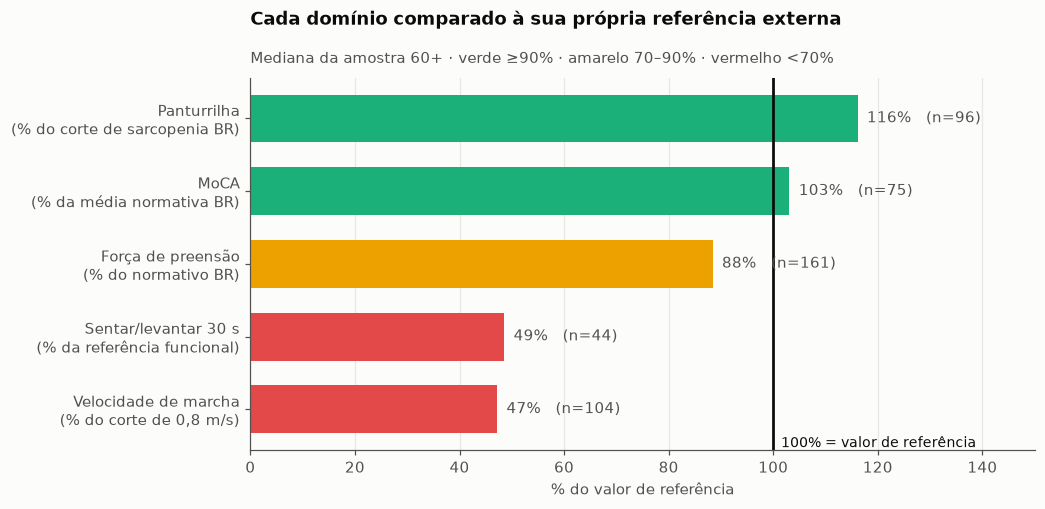

In [11]:
# Cada domínio na mesma escala: % do valor de referência externo.
dominios = []

p = mais["preensao_pct_norm"].dropna()
dominios.append(("Força de preensão\n(% do normativo BR)", p.median(), len(p)))

sl = mais["sentar_levantar_pct_ref"].dropna()
dominios.append(("Sentar/levantar 30 s\n(% da referência funcional)", sl.median(), len(sl)))

# Panturrilha e MoCA viram % do corte / da média normativa para ficarem comparáveis.
pant = mais.apply(lambda r: (r["panturrilha_d"] / nz.CORTE_PANTURRILHA_BR[r["sexo"]] * 100)
                  if pd.notna(r["panturrilha_d"]) and r["sexo"] in nz.CORTE_PANTURRILHA_BR
                  else np.nan, axis=1).dropna()
dominios.append(("Panturrilha\n(% do corte de sarcopenia BR)", pant.median(), len(pant)))

moca_pct = mais.apply(
    lambda r: (r["moca"] / nz._busca_faixa(nz.MOCA_NORMATIVO, r["idade"])[2] * 100)
    if pd.notna(r["moca"]) and nz._busca_faixa(nz.MOCA_NORMATIVO, r["idade"]) else np.nan,
    axis=1).dropna()
dominios.append(("MoCA\n(% da média normativa BR)", moca_pct.median(), len(moca_pct)))

vel = mais["velocidade_marcha"].dropna()
dominios.append(("Velocidade de marcha\n(% do corte de 0,8 m/s)",
                 (vel / nz.VELOCIDADE_CORTE_OMS * 100).median(), len(vel)))

dados = pd.DataFrame(dominios, columns=["domínio", "mediana (%)", "n"]).sort_values("mediana (%)")

fig, ax = plt.subplots(figsize=(9.2, 4.4))
# Emphasis: o domínio comprometido é o ponto; os preservados são contexto.
cores = [VERMELHO if v < 70 else (AMARELO if v < 90 else AQUA) for v in dados["mediana (%)"]]
barras = ax.barh(dados["domínio"], dados["mediana (%)"], color=cores, height=0.66)
for b, (_, r) in zip(barras, dados.iterrows()):
    ax.text(b.get_width() + 1.8, b.get_y() + b.get_height()/2,
            f"{r['mediana (%)']:.0f}%   (n={int(r['n'])})",
            va="center", fontsize=9.5, color=TINTA2)
ax.axvline(100, color=TINTA, linewidth=1.8)
ax.text(101.5, -0.52, "100% = valor de referência", fontsize=9, color=TINTA)
rotule(ax, "Cada domínio comparado à sua própria referência externa",
       "Mediana da amostra 60+ · verde ≥90% · amarelo 70–90% · vermelho <70%",
       xlab="% do valor de referência")
so_x(ax)
ax.set_xlim(0, 150)
plt.show()

### A narrativa que esse gráfico conta

O comprometimento desta população **não é global — é localizado**:

- **Preservados:** força de preensão (≈88% do normativo), circunferência de
  panturrilha (bem acima do corte de sarcopenia) e cognição (na média normativa
  brasileira ajustada por idade).
- **Comprometido:** capacidade funcional de membros inferiores. Apenas **3 de 44
  pacientes** alcançam a referência do Senior Fitness Test no sentar/levantar, com
  mediana de 7 repetições contra 15 esperadas.

Isso é clinicamente coerente e explica o resultado do notebook 01. A deficiência é
de membros inferiores; os braços são **mais** usados que na população geral
(muletas, andador, propulsão de cadeira), o que preserva a preensão. Medidas
globais de força e massa muscular não capturam o risco **porque não é ali que está
o problema.**

E responde direto a pergunta da AACD sobre quais testes diferenciam: os que medem
reserva global (preensão, panturrilha, cognição) descrevem bem a população, mas não
discriminam quem cai. Quem discrimina é o que mede **função de membro inferior**.

---
## 4. Redundância: quais testes repetem informação

A bateria tem 11 medidas. A pergunta da AACD — *"quais dão trabalho mas não
diferenciam ninguém?"* — é, estatisticamente, uma pergunta sobre **correlação**:
dois testes muito correlacionados medem a mesma coisa, e o mais caro pode sair.

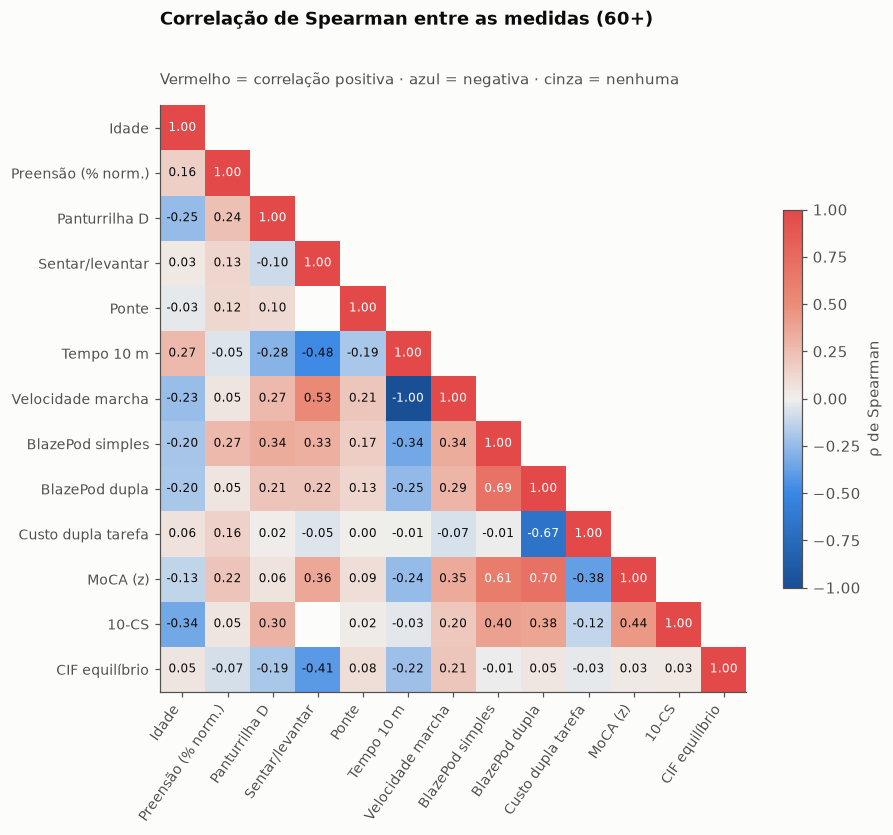

In [12]:
MEDIDAS = {
    "idade": "Idade", "preensao_pct_norm": "Preensão (% norm.)",
    "panturrilha_d": "Panturrilha D", "sentar_levantar": "Sentar/levantar",
    "ponte": "Ponte", "tempo_10m": "Tempo 10 m",
    "velocidade_marcha": "Velocidade marcha", "reacao": "BlazePod simples",
    "reacao_dt": "BlazePod dupla", "custo_dupla_tarefa": "Custo dupla tarefa",
    "moca_z": "MoCA (z)", "dez_cs": "10-CS", "cif_equilibrio": "CIF equilíbrio",
}
sub = mais[list(MEDIDAS)].astype(float).rename(columns=MEDIDAS)
# Spearman: robusto a outlier e não exige linearidade.
corr = sub.corr(method="spearman", min_periods=20)
pares_n = sub.notna().astype(int).T.dot(sub.notna().astype(int))

fig, ax = plt.subplots(figsize=(8.6, 7.2))
# Correlação é polaridade (±) -> escala divergente azul/vermelho, cinza no meio.
from matplotlib.colors import LinearSegmentedColormap
divergente = LinearSegmentedColormap.from_list(
    "div", [AZUIS[5], AZUIS[3], NEUTRO_DIV, "#eb8d78", VERMELHO])
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
plot = corr.mask(mascara)
im = ax.imshow(plot, cmap=divergente, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=55, ha="right", fontsize=9)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=9)
for i in range(len(corr)):
    for j in range(i + 1):
        v = corr.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.6,
                    color="white" if abs(v) > 0.55 else TINTA)
ax.grid(False)
rotule(ax, "Correlação de Spearman entre as medidas (60+)",
       "Vermelho = correlação positiva · azul = negativa · cinza = nenhuma")
plt.colorbar(im, ax=ax, shrink=0.62, label="ρ de Spearman")
plt.show()

In [13]:
# Pares redundantes: |rho| alto E com número de pares suficiente para confiar.
pares = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i + 1:]:
        rho, n = corr.loc[a, b], pares_n.loc[a, b]
        if pd.notna(rho) and n >= 25:
            pares.append({"medida A": a, "medida B": b, "ρ": round(rho, 3),
                          "n pares": int(n), "|ρ|": abs(rho)})
pares = pd.DataFrame(pares).sort_values("|ρ|", ascending=False)
print("PARES MAIS REDUNDANTES (|ρ| ≥ 0,70)\n" + "=" * 62)
print(pares[pares["|ρ|"] >= 0.70][["medida A", "medida B", "ρ", "n pares"]].to_string(index=False))
print("\n\nPARES MENOS RELACIONADOS (|ρ| ≤ 0,12) — medem coisas independentes\n" + "=" * 62)
print(pares[pares["|ρ|"] <= 0.12][["medida A", "medida B", "ρ", "n pares"]].head(12).to_string(index=False))

PARES MAIS REDUNDANTES (|ρ| ≥ 0,70)
      medida A          medida B      ρ  n pares
    Tempo 10 m Velocidade marcha -1.000      104
BlazePod dupla          MoCA (z)  0.703       72


PARES MENOS RELACIONADOS (|ρ| ≤ 0,12) — medem coisas independentes
          medida A           medida B      ρ  n pares
Custo dupla tarefa              10-CS -0.118       63
     Panturrilha D              Ponte  0.102       56
     Panturrilha D    Sentar/levantar -0.101       38
             Ponte           MoCA (z)  0.087       49
             Ponte     CIF equilíbrio  0.082      112
Preensão (% norm.)     CIF equilíbrio -0.074      160
 Velocidade marcha Custo dupla tarefa -0.067      102
             Idade Custo dupla tarefa  0.065      159
     Panturrilha D           MoCA (z)  0.060       43
             Idade     CIF equilíbrio  0.054      162
Preensão (% norm.)         Tempo 10 m -0.050      129
Preensão (% norm.)     BlazePod dupla  0.050      157


### Leitura prática

Só **dois** pares passam de |ρ| = 0,70 em toda a bateria, e eles são de naturezas
opostas:

- `tempo_10m` × `velocidade_marcha`: ρ = **−1,00**. Não é achado, é aritmética — uma
  é o inverso da outra. Na modelagem, use só uma.
- `reacao_dt` × `moca_z`: ρ = **+0,70**. Esse é achado, e dos bons. Ver abaixo.

Todo o resto da matriz é fracamente correlacionado. Isso significa que a bateria
**não é redundante**: cada teste mede um eixo diferente. Cognição não prevê força,
reação não prevê marcha. Justifica manter a avaliação multidimensional, como as
diretrizes mundiais recomendam.

### O achado mais acionável desta seção

O BlazePod em dupla tarefa correlaciona forte com o MoCA. E a diferença de
cobertura entre os dois é enorme.

In [14]:
pares_cog = []
for motor in ["reacao", "reacao_dt"]:
    for cog in ["moca", "moca_z", "dez_cs"]:
        d = mais[[motor, cog]].astype(float).dropna()
        if len(d) >= 25:
            rho, pval = stats.spearmanr(d[motor], d[cog])
            pares_cog.append({"teste motor": MEDIDAS.get(motor, motor),
                              "teste cognitivo": MEDIDAS.get(cog, cog),
                              "ρ": round(rho, 3), "p": f"{pval:.1e}", "n": len(d)})
print(pd.DataFrame(pares_cog).to_string(index=False))

print("\nCobertura na aba 60+:")
for c in ["moca", "dez_cs", "reacao_dt"]:
    print(f"  {MEDIDAS.get(c, c):22} {mais[c].notna().mean()*100:5.1f}%  "
          f"(n={int(mais[c].notna().sum())})")

     teste motor teste cognitivo     ρ       p  n
BlazePod simples            moca 0.632 2.5e-09 72
BlazePod simples        MoCA (z) 0.610 1.3e-08 72
BlazePod simples           10-CS 0.395 1.3e-03 63
  BlazePod dupla            moca 0.723 7.7e-13 72
  BlazePod dupla        MoCA (z) 0.703 6.0e-12 72
  BlazePod dupla           10-CS 0.381 2.1e-03 63

Cobertura na aba 60+:
  moca                    45.2%  (n=75)
  10-CS                   39.2%  (n=65)
  BlazePod dupla          95.8%  (n=159)


Três coisas de uma vez:

1. **ρ = 0,72 entre BlazePod em dupla tarefa e MoCA** (p < 10⁻¹⁰, n = 72). Forte.
2. **A versão em dupla tarefa correlaciona MAIS com cognição do que a simples**
   (0,72 vs 0,63). Isso valida o desenho do teste: adicionar a tarefa cognitiva de
   fato puxa carga cognitiva, e não é só ruído.
3. **A cobertura é oposta.** MoCA: 45% dos pacientes, cerca de 10 minutos por
   pessoa. BlazePod em dupla tarefa: 96%, 30 segundos.

Daí sai uma recomendação concreta para a AACD: **quando não houver tempo ou
condição para o MoCA, o BlazePod em dupla tarefa carrega parte da mesma
informação.** Não substitui um rastreio cognitivo para diagnóstico — ρ de 0,72
deixa cerca de metade da variância de fora, e o documento é explícito que o
BlazePod é medida experimental sem ponto de corte. Mas para *triagem* num evento
com 280 pessoas, é a troca que cabe no relógio.

E explica por que o custo de dupla tarefa teve 96% de cobertura enquanto o MoCA
teve 45%: o teste rápido foi aplicável a quase todos, inclusive a quem tinha
limitação motora ou pouco tempo.

---
## 5. PCA: quantas dimensões reais tem a bateria?

Se 11 medidas se resumissem a 2 ou 3 fatores, a AACD poderia encurtar a avaliação
sem perder informação — e com 280 pacientes num evento de uma semana, isso vale
muito.

Cobertura de cada variável no PCA:
                    % preenchido
idade                      100.0
preensao_pct_norm           97.0
panturrilha_d               57.8
tempo_10m                   78.9
reacao                      98.2
custo_dupla_tarefa          95.8
cif_equilibrio              97.6

Casos completos: 76/166 — imputando pela mediana


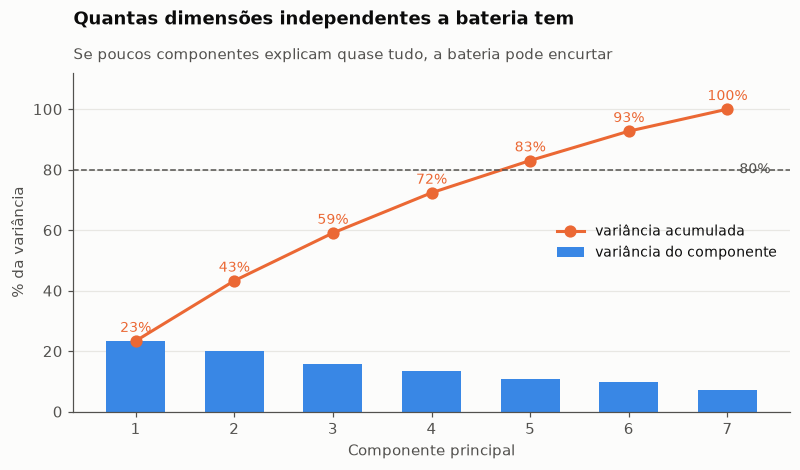


Componentes necessários para 80% da variância: 5 de 7


In [15]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Núcleo com cobertura razoável; velocidade sai porque é tempo_10m invertido.
NUCLEO_PCA = ["idade", "preensao_pct_norm", "panturrilha_d", "tempo_10m",
              "reacao", "custo_dupla_tarefa", "cif_equilibrio"]
X = mais[NUCLEO_PCA].astype(float)
print("Cobertura de cada variável no PCA:")
print((X.notna().mean() * 100).round(1).to_frame("% preenchido").to_string())
print(f"\nCasos completos: {X.dropna().shape[0]}/{len(X)} — imputando pela mediana")

pca = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                    PCA(random_state=7)).fit(X)
modelo_pca = pca.named_steps["pca"]
explicada = modelo_pca.explained_variance_ratio_ * 100
acumulada = explicada.cumsum()

fig, ax = plt.subplots(figsize=(8.4, 4))
comps = np.arange(1, len(explicada) + 1)
barras = ax.bar(comps, explicada, color=AZUIS[3], width=0.6, label="variância do componente")
ax.plot(comps, acumulada, color=LARANJA, marker="o", markersize=7, linewidth=2,
        label="variância acumulada")
for c, a in zip(comps, acumulada):
    ax.text(c, a + 3, f"{a:.0f}%", ha="center", fontsize=9, color=LARANJA)
ax.axhline(80, color=TINTA2, linestyle="--", linewidth=1)
ax.text(len(comps) + 0.08, 80, " 80%", fontsize=9, color=TINTA2, va="center")
rotule(ax, "Quantas dimensões independentes a bateria tem",
       "Se poucos componentes explicam quase tudo, a bateria pode encurtar",
       xlab="Componente principal", ylab="% da variância")
so_y(ax)
ax.set_xticks(comps); ax.set_ylim(0, 112)
ax.legend(loc="center right", fontsize=9)
plt.show()

n80 = int(np.searchsorted(acumulada, 80) + 1)
print(f"\nComponentes necessários para 80% da variância: {n80} de {len(explicada)}")

In [16]:
cargas = pd.DataFrame(
    modelo_pca.components_[:3].T,
    index=[MEDIDAS.get(c, c) for c in NUCLEO_PCA],
    columns=["CP1", "CP2", "CP3"]).round(3)
print("Cargas dos três primeiros componentes (o que cada eixo representa):\n")
print(cargas.to_string())
print("\nMedida que mais pesa em cada componente:")
for cp in cargas.columns:
    print(f"  {cp}: {cargas[cp].abs().idxmax()}  (carga {cargas.loc[cargas[cp].abs().idxmax(), cp]:+.2f})")

Cargas dos três primeiros componentes (o que cada eixo representa):

                      CP1    CP2    CP3
Idade              -0.421  0.355  0.361
Preensão (% norm.)  0.191  0.642  0.246
Panturrilha D       0.501  0.215 -0.280
Tempo 10 m         -0.429  0.338 -0.338
BlazePod simples    0.589  0.075  0.114
Custo dupla tarefa  0.066  0.325  0.466
CIF equilíbrio      0.004 -0.436  0.622

Medida que mais pesa em cada componente:
  CP1: BlazePod simples  (carga +0.59)
  CP2: Preensão (% norm.)  (carga +0.64)
  CP3: CIF equilíbrio  (carga +0.62)


**São necessários 5 dos 7 componentes para explicar 80% da variância**, e o
primeiro componente sozinho responde por apenas 23%. Uma bateria redundante teria
2 ou 3 componentes carregando quase tudo — aqui isso não acontece.

As cargas confirmam: cada componente é dominado por um domínio diferente (CP1 pela
reação, CP2 pela preensão, CP3 pelo equilíbrio da CIF). A bateria mede eixos
genuinamente independentes.

A conclusão para a AACD é de mão dupla. **Não dá para encurtar a bateria cortando
testes redundantes, porque praticamente não há redundância** — cada teste traz
informação própria. O que dá para cortar é pelo outro critério: o que foi
preenchido em pouca gente ou não discrimina. `Braço D/E` e `Diagnóstico Funcional`
têm valor conceitual mas cobertura baixa; e a substituição MoCA → BlazePod em dupla
tarefa (seção 4) economiza tempo sem perder tudo.

---
## 6. Perfis de paciente — uma tentativa que não deu certo

Em vez de perguntar "o que prevê queda?", podemos perguntar "que tipos de paciente
existem?". Isso é **não supervisionado**: a clusterização não vê o desfecho. Se os
grupos que emergissem tivessem taxas de queda diferentes, seria informação genuína.

Adianto o resultado porque ele é negativo, e resultado negativo também conta: **não
existem perfis separáveis nesta base.** As células abaixo mostram por quê.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

VARS_CLUSTER = ["idade", "preensao_pct_norm", "tempo_10m", "reacao",
                "custo_dupla_tarefa", "cif_equilibrio", "aditamento_ord"]
Xc = mais[VARS_CLUSTER].astype(float)
prep = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
Xp = prep.fit_transform(Xc)

avaliacao = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=25, random_state=7).fit(Xp)
    avaliacao.append({"k": k, "silhueta": round(silhouette_score(Xp, km.labels_), 3)})
avaliacao = pd.DataFrame(avaliacao)
print(avaliacao.to_string(index=False))
melhor_k = int(avaliacao.loc[avaliacao["silhueta"].idxmax(), "k"])
print(f"\nMelhor separação: k = {melhor_k}")
print("(silhueta vai de -1 a 1; acima de 0,5 é separação boa, 0,25–0,5 é fraca)")

 k  silhueta
 2     0.180
 3     0.151
 4     0.174
 5     0.176
 6     0.169

Melhor separação: k = 2
(silhueta vai de -1 a 1; acima de 0,5 é separação boa, 0,25–0,5 é fraca)


In [18]:
km = KMeans(n_clusters=melhor_k, n_init=50, random_state=7).fit(Xp)
mais["perfil"] = km.labels_

resumo = mais.groupby("perfil").agg(
    pacientes=("ID", "size"),
    idade=("idade", "median"),
    preensao_pct=("preensao_pct_norm", "median"),
    tempo_10m=("tempo_10m", "median"),
    reacao=("reacao", "median"),
    custo_dt=("custo_dupla_tarefa", "median"),
    cif=("cif_equilibrio", "median"),
    anda_pct=("anda", lambda s: round(s.mean() * 100, 0)),
    polifarmacia_pct=("polifarmacia_bin", lambda s: round(s.mean() * 100, 0)),
).round(1)
com_desfecho = mais[mais["caiu"].notna()]
resumo["taxa de queda (%)"] = (com_desfecho.groupby("perfil")["caiu"]
                               .mean().mul(100).round(1))
resumo["taxa recorrente (%)"] = (com_desfecho.groupby("perfil")["queda_recorrente"]
                                 .mean().mul(100).round(1))
resumo

,pacientes,idade,preensao_pct,tempo_10m,reacao,custo_dt,cif,anda_pct,polifarmacia_pct,taxa de queda (%),taxa recorrente (%)
perfil,,,,,,,,,,,
0,108,68.0,89.5,36.0,29.0,31.2,0.0,56.0,75.0,54.8,30.8
1,58,66.5,87.4,14.0,33.5,29.8,3.0,81.0,52.0,54.4,33.3


A taxa de queda difere entre os perfis? chi² p = 1.0000
Melhor silhueta obtida: 0.180

Leitura: silhueta abaixo de 0,25 indica que os grupos praticamente não se
separam, e o p do chi² confirma que eles não diferem em queda. A população é
um contínuo, não um conjunto de tipos distintos.


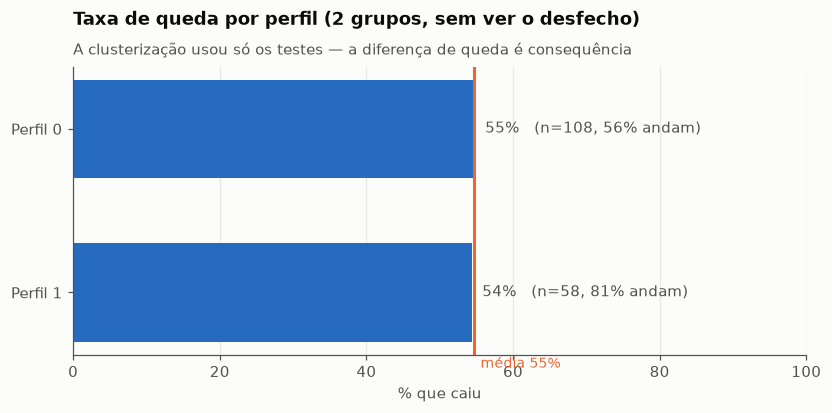

In [19]:
tab = pd.crosstab(com_desfecho["perfil"], com_desfecho["caiu"])
chi = stats.chi2_contingency(tab.values)
print(f"A taxa de queda difere entre os perfis? chi² p = {chi.pvalue:.4f}")
print(f"Melhor silhueta obtida: {avaliacao['silhueta'].max():.3f}")
print("\nLeitura: silhueta abaixo de 0,25 indica que os grupos praticamente não se")
print("separam, e o p do chi² confirma que eles não diferem em queda. A população é")
print("um contínuo, não um conjunto de tipos distintos.")

ordenado = resumo.sort_values("taxa de queda (%)")
fig, ax = plt.subplots(figsize=(8.6, 3.4))
barras = ax.barh([f"Perfil {i}" for i in ordenado.index],
                 ordenado["taxa de queda (%)"], color=AZUIS[4], height=0.6)
for b, (idx, r) in zip(barras, ordenado.iterrows()):
    ax.text(b.get_width() + 1.4, b.get_y() + b.get_height()/2,
            f"{r['taxa de queda (%)']:.0f}%   (n={int(r['pacientes'])}, "
            f"{r['anda_pct']:.0f}% andam)", va="center", fontsize=9.5, color=TINTA2)
media = com_desfecho["caiu"].mean() * 100
ax.axvline(media, color=LARANJA, linewidth=2)
ax.text(media + 0.9, -0.46, f"média {media:.0f}%", color=LARANJA, fontsize=9)
rotule(ax, f"Taxa de queda por perfil ({melhor_k} grupos, sem ver o desfecho)",
       "A clusterização usou só os testes — a diferença de queda é consequência",
       xlab="% que caiu")
so_x(ax)
ax.set_xlim(0, 100)
plt.show()

### Por que isso importa, mesmo sendo negativo

A silhueta máxima foi **0,18** — bem abaixo de 0,25, o piso para considerar que
existe alguma estrutura de grupos. E a taxa de queda **não difere** entre os
perfis.

Duas leituras, e as duas são úteis:

1. **A população é um contínuo de gravidade, não um conjunto de tipos.** Faz
   sentido: são diagnósticos diferentes (amputação, AVC, lesão medular, Parkinson)
   que produzem combinações contínuas de limitação, sem se agrupar em caixas.
2. **Não tente vender "perfis de paciente" para a AACD.** A clusterização é
   atraente num banner, mas aqui ela não achou nada. Apresentar grupos como se
   fossem reais seria o "número bonito e errado" que o enunciado do projeto pede
   para evitar.

O caminho que funciona para priorização é o escore ordinal do notebook 01, que
ordena ao longo do contínuo em vez de inventar categorias.

---
## 7. O teto honesto de modelagem

Com 161 pacientes e 88 quedas, existe um limite aritmético para o tamanho do
modelo. A regra prática na literatura clínica é de **10 eventos por variável**.

In [20]:
CANDIDATAS = {
    "idade": "contínua",
    "sexo_fem": "binária",
    "polifarmacia_bin": "binária",
    "anda": "binária",
    "aditamento_ord": "ordinal",
    "cif_equilibrio": "ordinal",
    "preensao_pct_norm": "contínua (normalizada)",
    "tempo_10m": "contínua",
    "reacao": "contínua",
    "custo_dupla_tarefa": "contínua (derivada)",
    "panturrilha_d": "contínua",
    "sentar_levantar": "contínua",
    "ponte": "contínua",
    "moca_z": "contínua (normalizada)",
    "dez_cs": "contínua",
}
cob = pd.DataFrame([
    {"variável": v, "tipo": t,
     "% preenchido": round(mais[v].notna().mean() * 100, 1)}
    for v, t in CANDIDATAS.items()
]).sort_values("% preenchido", ascending=False)
cob

,variável,tipo,% preenchido
0,idade,contínua,100.0
1,sexo_fem,binária,100.0
3,anda,binária,100.0
8,reacao,contínua,98.2
5,cif_equilibrio,ordinal,97.6
6,preensao_pct_norm,contínua (normalizada),97.0
9,custo_dupla_tarefa,contínua (derivada),95.8
2,polifarmacia_bin,binária,86.7
7,tempo_10m,contínua,78.9
4,aditamento_ord,ordinal,75.3


In [21]:
eventos = int(mais["caiu"].sum())
print(f"Eventos (quedas) disponíveis: {eventos}")
print(f"Teto pela regra de 10 eventos por variável: {eventos // 10} variáveis\n")

# Quantos casos completos sobram conforme se adicionam variáveis, por cobertura.
ordem = cob["variável"].tolist()
linhas, atual = [], []
for v in ordem:
    atual.append(v)
    completos = mais[atual + ["caiu"]].dropna().shape[0]
    linhas.append({"nº de variáveis": len(atual), "última incluída": v,
                   "casos completos": completos,
                   "eventos ~": int(completos * mais["caiu"].mean())})
pd.DataFrame(linhas)

Eventos (quedas) disponíveis: 88
Teto pela regra de 10 eventos por variável: 8 variáveis



,nº de variáveis,última incluída,casos completos,eventos ~
0,1,idade,161,88
1,2,sexo_fem,161,88
2,3,anda,161,88
3,4,reacao,161,88
4,5,cif_equilibrio,161,88
5,6,preensao_pct_norm,159,86
6,7,custo_dupla_tarefa,155,84
7,8,polifarmacia_bin,140,76
8,9,tempo_10m,115,62
9,10,aditamento_ord,109,59


A tabela mostra o custo de cada variável adicional. Com **8 variáveis** o teto já
foi atingido; e a partir de `sentar_levantar` a amostra completa desaba, porque ela
e `ponte` são protocolos alternativos (notebook 01, seção 6).

**Conclusão de modelagem:** um modelo honesto aqui tem 6 a 8 variáveis, usa
imputação declarada (não exclusão de casos), validação cruzada repetida, e é
comparado contra a classe majoritária. Qualquer coisa além disso está decorando os
161 pacientes.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# Núcleo enxuto, dentro do teto, só com variáveis de boa cobertura.
NUCLEO = ["idade", "sexo_fem", "polifarmacia_bin", "anda", "aditamento_ord",
          "cif_equilibrio", "preensao_pct_norm", "custo_dupla_tarefa"]
aval = mais[mais["caiu"].notna()].copy()
X = aval[NUCLEO].astype(float)
y = aval["caiu"].astype(int)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=7)

modelos = {
    "Classe majoritária (piso)": None,
    "Regressão logística": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(max_iter=2000)),
    "Random forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=400, min_samples_leaf=5, random_state=7)),
}
saida = []
for nome, mod in modelos.items():
    if mod is None:
        saida.append({"modelo": nome, "acurácia (%)": round(max(y.mean(), 1 - y.mean()) * 100, 1),
                      "AUC": "—", "desvio da AUC": "—"})
        continue
    acc = cross_val_score(mod, X, y, cv=cv, scoring="accuracy")
    auc = cross_val_score(mod, X, y, cv=cv, scoring="roc_auc")
    saida.append({"modelo": nome, "acurácia (%)": round(acc.mean() * 100, 1),
                  "AUC": round(auc.mean(), 3), "desvio da AUC": round(auc.std(), 3)})
pd.DataFrame(saida)

,modelo,acurácia (%),AUC,desvio da AUC
0,Classe majoritária (piso),54.7,—,—
1,Regressão logística,55.1,0.551,0.088
2,Random forest,53.8,0.513,0.073


Nenhum modelo supera o piso de forma convincente, e a AUC fica na faixa de
discriminação **modesta**. O random forest, com mais capacidade, não ganha da
regressão logística — sinal clássico de que não há sinal escondido esperando um
modelo mais potente: o limite está nos dados, não no algoritmo.

Isso confirma, por outro caminho, o resultado do notebook 01. E é consistente com
o que o próprio documento da AACD diz sobre a velocidade de marcha: *"a capacidade
de uma única medida prever uma queda individual é apenas moderada"* — risco
relativo de ~1,27. Se a medida mais recomendada do mundo tem RR 1,27, não era
razoável esperar que esta bateria previsse queda individual.

---
## 8. O que dá para fazer com o que temos

Reorganizando pelo que os dados sustentam, do mais sólido ao mais frágil.

### Sustenta bem — pode ir para o relatório e o banner

**1. Caracterizar a população contra referências externas brasileiras.**
É a contribuição mais forte e mais original: ninguém publicou como essas medidas se
comportam em adultos e idosos com deficiência física atendidos em reabilitação. O
achado principal já está pronto: o comprometimento é **localizado em membros
inferiores**, com preensão, massa muscular e cognição preservadas em relação ao
normativo brasileiro.

**2. Mostrar que os cortes importados não se aplicam.**
87% "alterados" no MoCA pelo corte internacional contra z mediano de +0,13 pelo
normativo brasileiro ajustado por idade. Isso é resultado publicável e tem
consequência prática imediata para a instituição.

**3. Documentar o paradoxo da exposição.**
Quem anda cai mais que quem usa cadeira (61% vs 39%, p = 0,015). Simples de
explicar, contraintuitivo e metodologicamente importante: qualquer análise futura
de quedas nesta população precisa estratificar por mobilidade.

**4. Os dois fatores que sobreviveram, entre quem anda.**
Polifarmácia (70% vs 46%, p ≈ 0,03) e força de membros inferiores em queda
recorrente (p ≈ 0,02). Ambos acionáveis: revisão de medicação e treino de força.

**5. A substituição MoCA → BlazePod em dupla tarefa.**
ρ = 0,72 entre os dois (p < 10⁻¹⁰), com 96% de cobertura contra 45% do MoCA e 30
segundos contra 10 minutos. Para triagem num evento de massa, é a troca mais
rentável que os dados apontam — e de quebra valida o desenho do teste de dupla
tarefa, já que a versão com carga cognitiva correlaciona mais com o MoCA do que a
simples.

**6. A bateria não é redundante.**
5 de 7 componentes para 80% da variância, CP1 com apenas 23%. Cada teste mede um
eixo próprio. Isso responde à pergunta da AACD pelo lado inverso do esperado: não
há testes repetidos para cortar; o que se corta é o que tem cobertura baixa.

**7. O painel de indicadores e o escore de alerta.**
Para ordenar a fila de prevenção, com a ressalva de AUC ≈ 0,6 declarada.

### Sustenta com ressalva — vale fazer, com o limite escrito

**8. Comparação 60+ vs 60−.** A amostra mais jovem é útil como contraste
(velocidade mediana 0,83 vs 0,38 m/s), mas tem quase nenhum dado cognitivo (99%
de lacuna no MoCA), então a comparação é parcial.

**9. Assimetria de panturrilha.** Ideia boa do documento, calculável em apenas 38
pacientes e sem diferença detectada (p = 0,35). Reporte como inconclusivo por
falta de poder, não como ausência de efeito.

### Não sustenta — não force

**10. Perfis de paciente por clusterização.** Silhueta de 0,18 e χ² p = 1,0: os
grupos não se separam e não diferem em queda. A população é um contínuo. Resultado
negativo, e vale reportar como tal.

**11. Prever queda individual.** Com AUC ≈ 0,6 e RR de 1,27 para a melhor medida
isolada da literatura, não há como. Diga isso com clareza: é o resultado honesto.

**12. Qualquer conclusão causal.** As quedas aconteceram **antes** dos testes. A
base é transversal e retrospectiva; ela descreve associação, nunca causa.

**13. Modelo com mais de 8 variáveis.** O teto é aritmético.

### As quatro recomendações de coleta que mais rendem

| Recomendação | Custo | Retorno |
|---|---|---|
| **Escolaridade** | uma pergunta | destrava a interpretação correta do MoCA e do 10-CS no Brasil |
| **As outras 2 Perguntas-Chave** ("sente-se inseguro?", "tem medo de cair?") | duas perguntas | completa o 3KQ das diretrizes mundiais; a base só tem a primeira |
| **Exposição** (horas/dia em pé ou andando) | uma pergunta | é a variável que falta para resolver o paradoxo da seção 3 do notebook 01 |
| **Aplicar o braço em todos os 70 sem panturrilha** | já está no protocolo | recupera 57 pacientes sem nenhuma medida de massa muscular |

E três ajustes de formulário: lista fechada nos campos categóricos; códigos
distintos para "não aplicável" e "não realizado"; e registrar os **erros** do
BlazePod, que o documento diz que deveriam ser analisados e não estão na planilha.

In [23]:
# Base codificada e normalizada, pronta para modelagem.
os.makedirs("saidas", exist_ok=True)
DERIVADAS = ["sexo_fem", "equilibrio_em_pe", "polifarmacia_bin", "supervisao_bin",
             "caiu_bin", "queda_recorrente_bin", "queda_ultimo_mes_bin",
             "aditamento_ord", "nivel_marcha_ord", "usa_cadeira", "anda",
             "preensao_pct_norm", "moca_z", "dez_cs_faixa",
             "sentar_levantar_pct_ref", "sarcopenia_ewgsop2",
             "panturrilha_abaixo_br", "assimetria_panturrilha",
             "tem_massa_muscular", "perfil"] + cols_dx

modelagem = pd.concat([mais, menos], ignore_index=True)
modelagem.to_csv("saidas/base_modelagem.csv", index=False)

dicionario = pd.DataFrame([
    {"variável": v, "tipo": str(modelagem[v].dtype),
     "% preenchido (60+)": round(mais[v].notna().mean() * 100, 1) if v in mais else np.nan}
    for v in DERIVADAS if v in modelagem.columns
])
dicionario.to_csv("saidas/dicionario_variaveis.csv", index=False)

print(f"saidas/base_modelagem.csv      : {modelagem.shape[0]} × {modelagem.shape[1]}")
print(f"saidas/dicionario_variaveis.csv: {len(dicionario)} variáveis derivadas")
dicionario

saidas/base_modelagem.csv      : 282 × 73
saidas/dicionario_variaveis.csv: 29 variáveis derivadas


,variável,tipo,% preenchido (60+)
0,sexo_fem,Int8,100.0
1,equilibrio_em_pe,Int8,97.6
2,polifarmacia_bin,Int8,86.7
3,supervisao_bin,Int8,7.2
4,caiu_bin,Int8,97.0
5,queda_recorrente_bin,Int8,97.0
6,queda_ultimo_mes_bin,Int8,97.0
7,aditamento_ord,Int8,75.3
8,nivel_marcha_ord,Int8,55.4
9,usa_cadeira,Int8,100.0


---
## Resumo

**Codificação.** Quatro tipos, cada um pelo motivo certo: binária para sexo e
polifarmácia, ordinal onde a ordem é clínica (aditamento, CIF, nível de marcha),
one-hot com cauda agrupada para diagnóstico, e contínua normalizada pelos
normativos brasileiros.

**O ganho maior.** Normalizar pelo normativo brasileiro ajustado por idade em vez
de usar corte importado. Transforma "87% alterados, inútil" em uma variável
contínua que distribui a população e revela que a cognição está preservada.

**Duas correções ao notebook 01.** Circunferência do braço é a medida substituta
da panturrilha (confirmado: os 13 pacientes com braço medido são exatamente os sem
panturrilha, p < 0,001), e o corte EWGSOP2 é 27/16, não 30/20.

**O retrato.** Comprometimento localizado em membros inferiores; preensão, massa
muscular e cognição preservadas. Isso explica por que as medidas globais não
discriminam quem cai — e responde diretamente à pergunta da AACD sobre quais testes
valem o trabalho.

**A bateria.** Não é redundante — 5 de 7 componentes para 80% da variância. A
única troca que os dados sustentam é MoCA → BlazePod em dupla tarefa (ρ = 0,72,
com o dobro da cobertura e um vigésimo do tempo).

**O que não funcionou.** Clusterização: silhueta 0,18 e χ² p = 1,0. A população é
um contínuo de gravidade, não um conjunto de perfis. Vale reportar como resultado
negativo em vez de forçar grupos que não existem.

**O limite.** AUC ≈ 0,6, teto de 8 variáveis, base transversal e retrospectiva. Os
dados permitem caracterizar e ordenar; não permitem prever queda individual nem
afirmar causa.